# Image Caption Generation — EfficientNetB0 + LSTM
### GPU-Accelerated | TensorFlow 2.10 Compatible
- **Feature Extractor**: EfficientNetB0 (pretrained on ImageNet)
- **Sequence Model**: LSTM with LayerNormalization
- **GPU**: Mixed precision (float16) + memory growth
- **Training**: Data generator (memory-safe)
- **Evaluation**: BLEU-1 through BLEU-4 scores

## 1. Install Dependencies

In [ ]:
!pip install -q tensorflow==2.10.* scikit-learn matplotlib nltk tqdm pillow

## 2. Import Libraries & Configure GPU

In [1]:
import numpy as np
import pandas as pd
import os, re, pickle, json, warnings
import matplotlib.pyplot as plt
import tensorflow as tf

# === GPU Configuration (must be before any TF operations) ===
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU memory growth enabled for {len(gpus)} GPU(s)')
    # Mixed precision for ~2x faster GPU training
    try:
        from tensorflow.keras import mixed_precision
        mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision (float16) enabled for faster training')
    except Exception:
        tf.keras.mixed_precision.set_global_policy('mixed_float16')
        print('Mixed precision (float16) enabled for faster training')
else:
    print('No GPU detected — running on CPU')

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Embedding, LSTM,
    BatchNormalization, GlobalAveragePooling2D,
    Concatenate, LayerNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu

warnings.filterwarnings('ignore')
print(f'TensorFlow version: {tf.__version__}')
print(f'Built with CUDA: {tf.test.is_built_with_cuda()}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')
print('All libraries imported successfully')

GPU memory growth enabled for 1 GPU(s)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 6GB Laptop GPU, compute capability 8.6
Mixed precision (float16) enabled for faster training
TensorFlow version: 2.10.0
Built with CUDA: True
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully


## 3. Configure Paths & Hyperparameters

In [4]:
IMAGE_DIR = r'C:\Users\Rehan\Documents\topic-model\DL_dataset\DL_dataset\Images'
CAPTION_FILE = r'C:\Users\Rehan\Documents\topic-model\captions_old.csv'
OUTPUT_DIR = r'C:\Users\Rehan\Documents\topic-model\caption_outputs'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

# Hyperparameters (tuned for GPU)
IMG_SIZE = 224
FEATURE_DIM = 1280  # EfficientNetB0 output dim
EMBED_DIM = 256
LSTM_UNITS = 256
DENSE_UNITS = 256
DROPOUT_RATE = 0.4
BATCH_SIZE = 128    # Larger batch for GPU
EPOCHS = 30
LEARNING_RATE = 1e-3

print(f'Image Dir: {IMAGE_DIR}')
print(f'Caption File: {CAPTION_FILE}')
print(f'Output Dir: {OUTPUT_DIR}')
print(f'Batch Size: {BATCH_SIZE} (GPU-optimized)')

Image Dir: C:\Users\Rehan\Documents\topic-model\DL_dataset\DL_dataset\Images
Caption File: C:\Users\Rehan\Documents\topic-model\captions_old.csv
Output Dir: C:\Users\Rehan\Documents\topic-model\caption_outputs
Batch Size: 128 (GPU-optimized)


## 4. Load and Clean Captions

In [5]:
df = pd.read_csv(CAPTION_FILE)
print(f'Raw CSV shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Raw CSV shape: (40455, 2)
Columns: ['image', 'caption']


,image,caption
0,1000268201_693b08cb0e.jpg,A child in a pink dress is climbing up a set o...
1,1000268201_693b08cb0e.jpg,A girl going into a wooden building .
2,1000268201_693b08cb0e.jpg,A little girl climbing into a wooden playhouse .
3,1000268201_693b08cb0e.jpg,A little girl climbing the stairs to her playh...
4,1000268201_693b08cb0e.jpg,A little girl in a pink dress going into a woo...


In [6]:
def clean_caption(text):
    """Clean and normalize caption text."""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Vectorized cleaning (much faster than iterrows on 40k rows)
df['caption_clean'] = df['caption'].apply(clean_caption)
df['word_count'] = df['caption_clean'].apply(lambda x: len(x.split()))

# Filter: keep captions with 2+ words
df_filtered = df[df['word_count'] >= 2].copy()

# Check which images exist on disk
existing_images = set(os.listdir(IMAGE_DIR))
df_filtered = df_filtered[df_filtered['image'].isin(existing_images)].copy()

# Build caption dictionary
captions_dict = {}
for img_name, caption in zip(df_filtered['image'], df_filtered['caption_clean']):
    caption_with_tokens = f'startseq {caption} endseq'
    if img_name not in captions_dict:
        captions_dict[img_name] = []
    captions_dict[img_name].append(caption_with_tokens)

print(f'Total unique images with captions: {len(captions_dict)}')
print(f'Total caption entries used: {len(df_filtered)}')
print(f'Skipped entries: {len(df) - len(df_filtered)}')

sample_key = list(captions_dict.keys())[0]
print(f'\nSample ({sample_key}):')
for c in captions_dict[sample_key][:2]:
    print(f'  {c}')

Total unique images with captions: 8090
Total caption entries used: 40448
Skipped entries: 7

Sample (1000268201_693b08cb0e.jpg):
  startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq
  startseq a girl going into a wooden building endseq


## 5. Build Tokenizer & Vocabulary

Total captions: 40448
Vocabulary size: 8780
Max caption length: 37
Mean caption length: 12.8


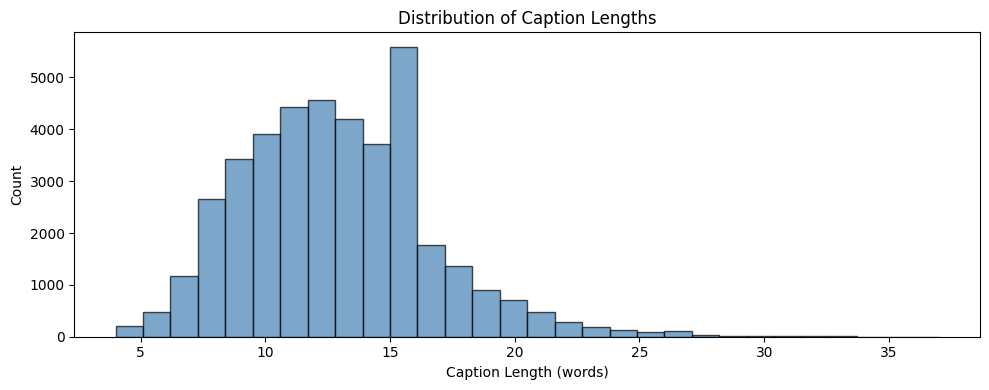

In [7]:
all_captions = [cap for caps in captions_dict.values() for cap in caps]
print(f'Total captions: {len(all_captions)}')

tokenizer = Tokenizer(oov_token='<unk>', filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(all_captions)

VOCAB_SIZE = len(tokenizer.word_index) + 1
caption_lengths = [len(c.split()) for c in all_captions]
MAX_LENGTH = max(caption_lengths)

print(f'Vocabulary size: {VOCAB_SIZE}')
print(f'Max caption length: {MAX_LENGTH}')
print(f'Mean caption length: {np.mean(caption_lengths):.1f}')

plt.figure(figsize=(10, 4))
plt.hist(caption_lengths, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Caption Length (words)')
plt.ylabel('Count')
plt.title('Distribution of Caption Lengths')
plt.tight_layout()
plt.show()

## 6. Train/Validation/Test Split

In [8]:
all_images = list(captions_dict.keys())
np.random.seed(42)

train_imgs, temp_imgs = train_test_split(all_images, test_size=0.2, random_state=42)
val_imgs, test_imgs = train_test_split(temp_imgs, test_size=0.5, random_state=42)

print(f'Train: {len(train_imgs)} images')
print(f'Val:   {len(val_imgs)} images')
print(f'Test:  {len(test_imgs)} images')

Train: 6472 images
Val:   809 images
Test:  809 images


## 7. Build Feature Extractor (EfficientNetB0)

In [9]:
def build_feature_extractor():
    base = EfficientNetB0(weights='imagenet', include_top=False,
                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
    base.trainable = False
    model = Model(inputs=base.input,
                  outputs=GlobalAveragePooling2D()(base.output))
    return model

feature_extractor = build_feature_extractor()
print(f'Feature extractor output shape: {feature_extractor.output_shape}')
print(f'Feature extractor total params: {feature_extractor.count_params():,}')

Feature extractor output shape: (None, 1280)
Feature extractor total params: 4,049,571


## 8. Extract and Cache Image Features

In [10]:
feature_cache_path = os.path.join(OUTPUT_DIR, 'efficientnet_features.pkl')

if os.path.exists(feature_cache_path):
    with open(feature_cache_path, 'rb') as f:
        features = pickle.load(f)
    print(f'Loaded cached features for {len(features)} images')
else:
    print('Extracting features in BATCHES (GPU-accelerated)...')
    features = {}
    all_img_list = list(captions_dict.keys())
    EXTRACT_BATCH = 32  # Process 32 images at once on GPU
    
    for start in tqdm(range(0, len(all_img_list), EXTRACT_BATCH),
                      desc='Batch extracting'):
        batch_names = all_img_list[start:start + EXTRACT_BATCH]
        batch_imgs = []
        valid_names = []
        
        for img_name in batch_names:
            img_path = os.path.join(IMAGE_DIR, img_name)
            try:
                img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
                img = img_to_array(img)
                batch_imgs.append(img)
                valid_names.append(img_name)
            except Exception as e:
                print(f'Error loading {img_name}: {e}')
        
        if batch_imgs:
            batch_array = preprocess_input(np.array(batch_imgs))
            batch_feats = feature_extractor.predict(batch_array, verbose=0)
            for name, feat in zip(valid_names, batch_feats):
                features[name] = feat.flatten()
    
    with open(feature_cache_path, 'wb') as f:
        pickle.dump(features, f)
    print(f'Extracted and saved features for {len(features)} images')

print(f'Feature vector shape: {list(features.values())[0].shape}')

Extracting features in BATCHES (GPU-accelerated)...


Batch extracting: 100%|██████████████████████████████████████████████████████████████| 253/253 [06:29<00:00,  1.54s/it]


Extracted and saved features for 8090 images
Feature vector shape: (1280,)


## 9. Data Generator (Memory-Safe)

In [11]:
class CaptionDataGenerator(Sequence):
    """Generates batches of (image_feature, partial_sequence) -> next_word.
    Uses a generator to avoid loading all sequences into memory."""
    
    def __init__(self, image_list, captions_dict, features, tokenizer,
                 max_length, vocab_size, batch_size, shuffle=True):
        self.image_list = [img for img in image_list if img in features]
        self.captions_dict = captions_dict
        self.features = features
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.vocab_size = vocab_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        
        self.pairs = []
        for img_name in self.image_list:
            for cap in self.captions_dict[img_name]:
                seq = self.tokenizer.texts_to_sequences([cap])[0]
                for i in range(1, len(seq)):
                    self.pairs.append((img_name, seq[:i], seq[i]))
        
        self.indices = np.arange(len(self.pairs))
        if self.shuffle:
            np.random.shuffle(self.indices)
    
    def __len__(self):
        return int(np.ceil(len(self.pairs) / self.batch_size))
    
    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        img_batch, seq_batch, out_batch = [], [], []
        
        for i in batch_indices:
            img_name, partial_seq, next_word = self.pairs[i]
            img_batch.append(self.features[img_name])
            seq_batch.append(partial_seq)
            out_batch.append(next_word)
        
        padded_seqs = pad_sequences(seq_batch, maxlen=self.max_length, padding='post')
        return [np.array(img_batch), np.array(padded_seqs)], np.array(out_batch)
    
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = CaptionDataGenerator(
    train_imgs, captions_dict, features, tokenizer,
    MAX_LENGTH, VOCAB_SIZE, BATCH_SIZE, shuffle=True
)
val_gen = CaptionDataGenerator(
    val_imgs, captions_dict, features, tokenizer,
    MAX_LENGTH, VOCAB_SIZE, BATCH_SIZE, shuffle=False
)

print(f'Train batches per epoch: {len(train_gen)}')
print(f'Val batches per epoch:   {len(val_gen)}')
print(f'Total train pairs: {len(train_gen.pairs)}')
print(f'Total val pairs:   {len(val_gen.pairs)}')

Train batches per epoch: 2985
Val batches per epoch:   367
Total train pairs: 382064
Total val pairs:   46924


## 10. Build Caption Model Architecture

In [12]:
def build_caption_model(vocab_size, max_length, feature_dim, embed_dim,
                         lstm_units, dense_units, dropout_rate):
    """
    Architecture:
      Image Branch:  Dense + BN + Dropout (with L2 regularization)
      Text Branch:   Embedding -> Dropout -> LSTM -> LayerNorm
      Fusion:        Concatenate -> Dense -> BN -> Dropout -> Softmax
    """
    reg = l2(1e-4)  # L2 regularization to reduce overfitting
    
    # === Image Branch ===
    img_input = Input(shape=(feature_dim,), name='image_input')
    img_dense = Dense(dense_units, activation='relu',
                      kernel_regularizer=reg, name='img_dense')(img_input)
    img_bn = BatchNormalization(name='img_bn')(img_dense)
    img_drop = Dropout(dropout_rate, name='img_dropout')(img_bn)
    
    # === Text Branch ===
    seq_input = Input(shape=(max_length,), name='seq_input')
    emb = Embedding(vocab_size, embed_dim, mask_zero=True, name='embedding')(seq_input)
    emb_drop = Dropout(dropout_rate, name='emb_dropout')(emb)
    lstm_out = LSTM(lstm_units, return_sequences=False, name='lstm')(emb_drop)
    lstm_norm = LayerNormalization(name='lstm_norm')(lstm_out)
    
    # === Fusion ===
    merged = Concatenate(name='concat')([img_drop, lstm_norm])
    
    x = Dense(dense_units, activation='relu',
              kernel_regularizer=reg, name='fusion_dense1')(merged)
    x = BatchNormalization(name='fusion_bn1')(x)
    x = Dropout(dropout_rate, name='fusion_dropout1')(x)
    
    x = Dense(dense_units // 2, activation='relu',
              kernel_regularizer=reg, name='fusion_dense2')(x)
    x = Dropout(dropout_rate * 0.5, name='fusion_dropout2')(x)
    
    # float32 output for numerical stability with mixed precision
    output = Dense(vocab_size, activation='softmax',
                   dtype='float32', name='output')(x)
    
    model = Model(inputs=[img_input, seq_input], outputs=output,
                  name='CaptionModel_EfficientNet_LSTM')
    return model

model = build_caption_model(
    vocab_size=VOCAB_SIZE,
    max_length=MAX_LENGTH,
    feature_dim=FEATURE_DIM,
    embed_dim=EMBED_DIM,
    lstm_units=LSTM_UNITS,
    dense_units=DENSE_UNITS,
    dropout_rate=DROPOUT_RATE
)

model.summary()

try:
    tf.keras.utils.plot_model(model, to_file=os.path.join(OUTPUT_DIR, 'model_architecture.png'),
                              show_shapes=True, show_layer_names=True, dpi=100)
    print('Model architecture plot saved.')
except Exception as e:
    print(f'Could not plot model (install pydot/graphviz): {e}')

Model: "CaptionModel_EfficientNet_LSTM"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 seq_input (InputLayer)         [(None, 37)]         0           []                               
                                                                                                  
 image_input (InputLayer)       [(None, 1280)]       0           []                               
                                                                                                  
 embedding (Embedding)          (None, 37, 256)      2247680     ['seq_input[0][0]']              
                                                                                                  
 img_dense (Dense)              (None, 256)          327936      ['image_input[0][0]']            
                                                                     

## 11. Compile Model

In [13]:
model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
print('Model compiled with Adam optimizer + L2 regularization')
print(f'Total parameters: {model.count_params():,}')

Model compiled with Adam optimizer + L2 regularization
Total parameters: 4,400,332


## 12. Train the Model

In [14]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=2, min_lr=1e-6, verbose=1
    ),
    ModelCheckpoint(
        os.path.join(MODELS_DIR, 'best_model.h5'),
        monitor='val_loss', save_best_only=True,
        verbose=1
    )
]

print(f'Starting training for up to {EPOCHS} epochs...')
print(f'Batch size: {BATCH_SIZE}')
print(f'Train batches: {len(train_gen)}, Val batches: {len(val_gen)}')
print(f'Device: {"/GPU:0" if gpus else "/CPU:0"}')
print('-' * 60)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

print('Training completed!')

Starting training for up to 30 epochs...
Batch size: 128
Train batches: 2985, Val batches: 367
Device: /GPU:0
------------------------------------------------------------
Epoch 1/30
2985/2985 [==============================] - ETA: 0s - loss: 4.0824 - accuracy: 0.3133
Epoch 1: val_loss improved from inf to 3.53546, saving model to C:\Users\Rehan\Documents\topic-model\caption_outputs\models\best_model.h5
2985/2985 [==============================] - 274s 84ms/step - loss: 4.0824 - accuracy: 0.3133 - val_loss: 3.5355 - val_accuracy: 0.3563 - lr: 0.0010
Epoch 2/30
2985/2985 [==============================] - ETA: 0s - loss: 3.4588 - accuracy: 0.3607
Epoch 2: val_loss improved from 3.53546 to 3.37483, saving model to C:\Users\Rehan\Documents\topic-model\caption_outputs\models\best_model.h5
2985/2985 [==============================] - 247s 83ms/step - loss: 3.4588 - accuracy: 0.3607 - val_loss: 3.3748 - val_accuracy: 0.3751 - lr: 0.0010
Epoch 3/30
2985/2985 [==============================] -

## 13. Plot Training Curves

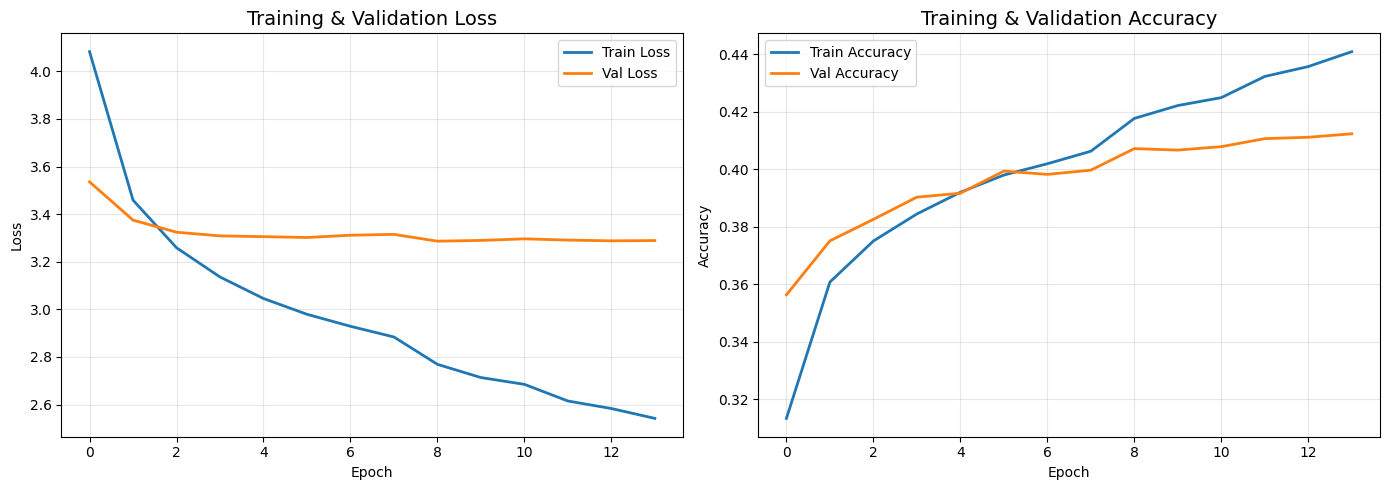

Training curves saved.


In [15]:
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[0].set_title('Training & Validation Loss', fontsize=14)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[1].set_title('Training & Validation Accuracy', fontsize=14)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
    plt.show()
    print('Training curves saved.')

plot_training_history(history)

## 14. Caption Generation (Greedy + Beam Search)

In [16]:
idx_to_word = {v: k for k, v in tokenizer.word_index.items()}

def generate_caption_greedy(model, feature, tokenizer, max_length):
    """Generate caption using greedy decoding."""
    in_text = 'startseq'
    for _ in range(max_length):
        seq = tokenizer.texts_to_sequences([in_text])[0]
        seq = pad_sequences([seq], maxlen=max_length, padding='post')
        pred = model.predict([np.array([feature]), seq], verbose=0)
        word_idx = np.argmax(pred[0])
        word = idx_to_word.get(word_idx, '')
        if word == 'endseq' or word == '':
            break
        in_text += ' ' + word
    return in_text.replace('startseq', '').strip()


def generate_caption_beam(model, feature, tokenizer, max_length, beam_width=3):
    """Generate caption using beam search for better quality."""
    sequences = [(['startseq'], 0.0)]
    
    for _ in range(max_length):
        all_candidates = []
        for seq_words, score in sequences:
            if seq_words[-1] == 'endseq':
                all_candidates.append((seq_words, score))
                continue
            
            seq_encoded = tokenizer.texts_to_sequences([' '.join(seq_words)])[0]
            seq_padded = pad_sequences([seq_encoded], maxlen=max_length, padding='post')
            pred = model.predict([np.array([feature]), seq_padded], verbose=0)[0]
            
            top_indices = np.argsort(pred)[-beam_width:]
            for idx in top_indices:
                word = idx_to_word.get(idx, '')
                if word == '':
                    continue
                new_score = score - np.log(pred[idx] + 1e-8)
                all_candidates.append((seq_words + [word], new_score))
        
        if not all_candidates:
            break
        sequences = sorted(all_candidates, key=lambda x: x[1])[:beam_width]
        
        if all(s[-1] == 'endseq' for s, _ in sequences):
            break
    
    best = sequences[0][0]
    caption = ' '.join([w for w in best if w not in ('startseq', 'endseq')])
    return caption

print('Caption generation functions defined.')

Caption generation functions defined.


## 15. Evaluate with BLEU Scores

In [17]:
def evaluate_bleu(model, test_images, captions_dict, features,
                  tokenizer, max_length, num_samples=200):
    """Evaluate model using BLEU-1 through BLEU-4 scores."""
    references = []
    hypotheses = []
    
    sample_imgs = [img for img in test_images if img in features][:num_samples]
    
    for img_name in tqdm(sample_imgs, desc='Evaluating BLEU'):
        refs = []
        for cap in captions_dict[img_name]:
            tokens = cap.split()
            tokens = [t for t in tokens if t not in ('startseq', 'endseq')]
            refs.append(tokens)
        references.append(refs)
        
        pred = generate_caption_greedy(model, features[img_name],
                                       tokenizer, max_length)
        hypotheses.append(pred.split())
    
    bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0))
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5, 0.5, 0, 0))
    bleu3 = corpus_bleu(references, hypotheses, weights=(0.33, 0.33, 0.33, 0))
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25))
    
    print(f'\n{"="*50}')
    print(f'BLEU Scores (on {len(sample_imgs)} test images):')
    print(f'  BLEU-1: {bleu1:.4f}')
    print(f'  BLEU-2: {bleu2:.4f}')
    print(f'  BLEU-3: {bleu3:.4f}')
    print(f'  BLEU-4: {bleu4:.4f}')
    print(f'{"="*50}')
    
    return {'bleu1': bleu1, 'bleu2': bleu2, 'bleu3': bleu3, 'bleu4': bleu4}

bleu_scores = evaluate_bleu(model, test_imgs, captions_dict, features,
                            tokenizer, MAX_LENGTH, num_samples=200)

Evaluating BLEU: 100%|███████████████████████████████████████████████████████████████| 200/200 [09:36<00:00,  2.88s/it]



BLEU Scores (on 200 test images):
  BLEU-1: 0.5577
  BLEU-2: 0.3839
  BLEU-3: 0.2526
  BLEU-4: 0.1670


## 16. Save All Artifacts

In [19]:
# Save final model (.h5 format for TF 2.10 compatibility)
model.save(os.path.join(MODELS_DIR, 'final_model.h5'))
print(f'Model saved: {os.path.join(MODELS_DIR, "final_model.h5")}')

# Save tokenizer
with open(os.path.join(OUTPUT_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)
print('Tokenizer saved.')

# Save config
config = {
    'vocab_size': VOCAB_SIZE,
    'max_length': MAX_LENGTH,
    'img_size': IMG_SIZE,
    'feature_dim': FEATURE_DIM,
    'embed_dim': EMBED_DIM,
    'lstm_units': LSTM_UNITS,
    'dense_units': DENSE_UNITS,
    'dropout_rate': DROPOUT_RATE,
    'batch_size': BATCH_SIZE,
    'bleu_scores': bleu_scores
}
with open(os.path.join(OUTPUT_DIR, 'config.json'), 'w') as f:
    json.dump(config, f, indent=2)
print('Config saved.')

Model saved: C:\Users\Rehan\Documents\topic-model\caption_outputs\models\final_model.h5
Tokenizer saved.
Config saved.


## 17. Visual Test — Generate Captions on Test Images

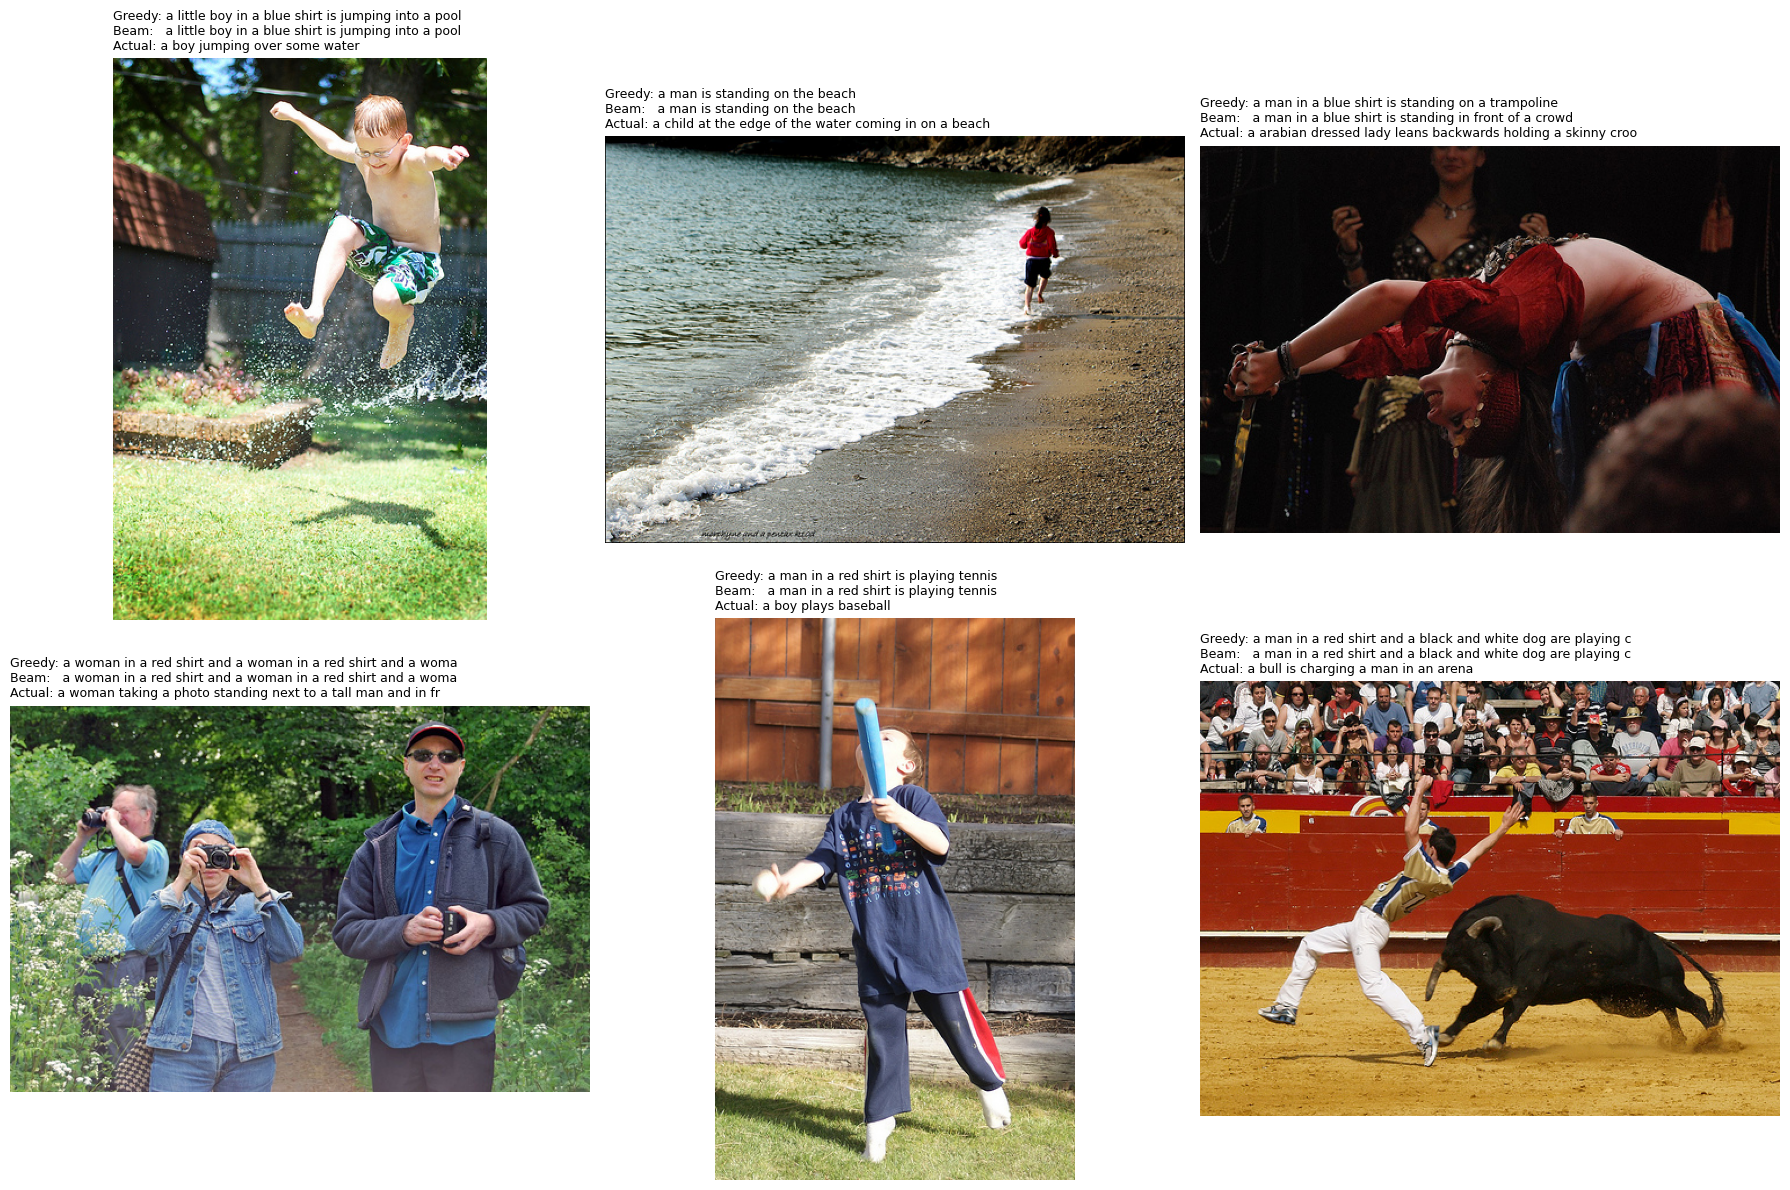

Sample predictions saved.


In [20]:
def visualize_predictions(model, test_images, captions_dict, features,
                          tokenizer, max_length, n=6):
    """Show test images with generated vs actual captions."""
    sample = [img for img in test_images if img in features][:n]
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    axes = axes.flatten()
    
    for i, img_name in enumerate(sample):
        img_path = os.path.join(IMAGE_DIR, img_name)
        img = plt.imread(img_path)
        
        greedy_cap = generate_caption_greedy(
            model, features[img_name], tokenizer, max_length
        )
        beam_cap = generate_caption_beam(
            model, features[img_name], tokenizer, max_length, beam_width=3
        )
        orig = captions_dict[img_name][0]
        orig = orig.replace('startseq', '').replace('endseq', '').strip()
        
        axes[i].imshow(img)
        axes[i].set_title(
            f'Greedy: {greedy_cap[:60]}\n'
            f'Beam:   {beam_cap[:60]}\n'
            f'Actual: {orig[:60]}',
            fontsize=9, ha='left', x=0
        )
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'sample_predictions.png'), dpi=150)
    plt.show()
    print('Sample predictions saved.')

visualize_predictions(model, test_imgs, captions_dict, features,
                      tokenizer, MAX_LENGTH, n=6)

## 18. Predict on a Custom / New Image

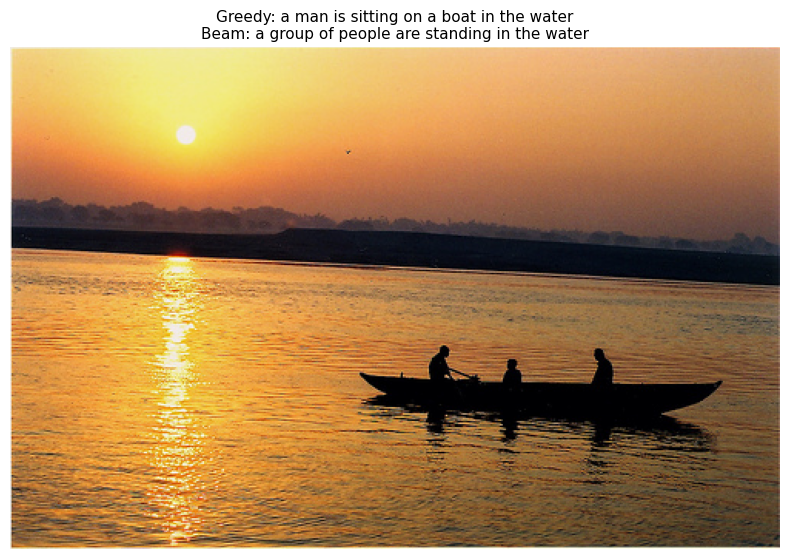


Greedy: a man is sitting on a boat in the water
Beam:   a group of people are standing in the water


In [24]:
def predict_custom_image(image_path, model, feature_extractor,
                         tokenizer, max_length):
    """
    Predict caption for any new image not in the dataset.
    Pass the path to any .jpg/.png image.
    """
    if not os.path.exists(image_path):
        print(f'Image not found: {image_path}')
        return
    
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    
    feature = feature_extractor.predict(img_array, verbose=0).flatten()
    
    greedy_caption = generate_caption_greedy(model, feature, tokenizer, max_length)
    beam_caption = generate_caption_beam(model, feature, tokenizer, max_length, beam_width=5)
    
    plt.figure(figsize=(8, 6))
    plt.imshow(plt.imread(image_path))
    plt.axis('off')
    plt.title(f'Greedy: {greedy_caption}\nBeam: {beam_caption}', fontsize=11)
    plt.tight_layout()
    plt.show()
    
    return {'greedy': greedy_caption, 'beam': beam_caption}


# === Test with a random test image ===
random_test_img = [img for img in test_imgs if img in features][0]
result = predict_custom_image(
    # os.path.join(IMAGE_DIR, random_test_img),
    r"C:\Users\Rehan\Documents\topic-model\DL_dataset\DL_dataset\Images\223299137_b0e81ac145.jpg",
    model, feature_extractor, tokenizer, MAX_LENGTH
)
print(f'\nGreedy: {result["greedy"]}')
print(f'Beam:   {result["beam"]}')

# === To test YOUR OWN image, uncomment and change path: ===
# result = predict_custom_image(
#     r'D:/path/to/your/image.jpg',
#     model, feature_extractor, tokenizer, MAX_LENGTH
# )

## 19. Model Summary Report

In [ ]:
print('=' * 60)
print('       MODEL TRAINING SUMMARY REPORT')
print('=' * 60)
print(f'\nArchitecture: EfficientNetB0 (frozen) + LSTM + Dense')
print(f'Feature Extractor: EfficientNetB0 (ImageNet pretrained)')
print(f'Image Size: {IMG_SIZE}x{IMG_SIZE}')
print(f'Feature Dim: {FEATURE_DIM}')
print(f'Embedding Dim: {EMBED_DIM}')
print(f'LSTM Units: {LSTM_UNITS}')
print(f'Vocabulary Size: {VOCAB_SIZE}')
print(f'Max Caption Length: {MAX_LENGTH}')
print(f'Dropout Rate: {DROPOUT_RATE}')
print(f'GPU: {tf.config.list_physical_devices("GPU")}')
print(f'Mixed Precision: {"Enabled" if gpus else "Disabled"}')
print(f'\nDataset:')
print(f'  Total Images: {len(captions_dict)}')
print(f'  Train: {len(train_imgs)}')
print(f'  Validation: {len(val_imgs)}')
print(f'  Test: {len(test_imgs)}')
print(f'\nTraining:')
print(f'  Epochs trained: {len(history.history["loss"])}')
print(f'  Final train loss: {history.history["loss"][-1]:.4f}')
print(f'  Final val loss: {history.history["val_loss"][-1]:.4f}')
print(f'  Best val loss: {min(history.history["val_loss"]):.4f}')
print(f'  Final train acc: {history.history["accuracy"][-1]:.4f}')
print(f'  Final val acc: {history.history["val_accuracy"][-1]:.4f}')
print(f'\nBLEU Scores:')
for k, v in bleu_scores.items():
    print(f'  {k.upper()}: {v:.4f}')
print(f'\nSaved Artifacts:')
print(f'  Model:     {os.path.join(MODELS_DIR, "final_model.h5")}')
print(f'  Best:      {os.path.join(MODELS_DIR, "best_model.h5")}')
print(f'  Tokenizer: {os.path.join(OUTPUT_DIR, "tokenizer.pkl")}')
print(f'  Config:    {os.path.join(OUTPUT_DIR, "config.json")}')
print(f'  Curves:    {os.path.join(OUTPUT_DIR, "training_curves.png")}')
print('=' * 60)